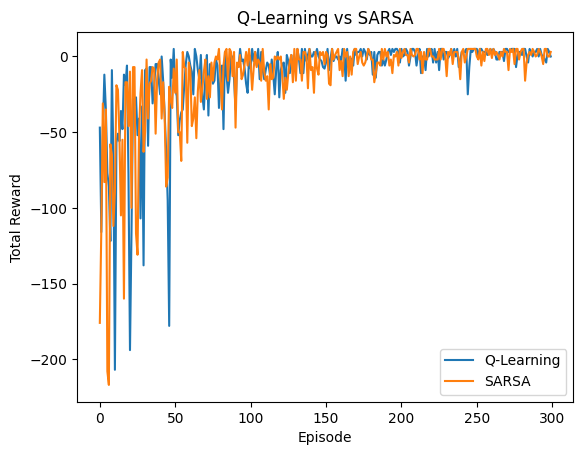

In [1]:
# q_learning_vs_sarsa.py

import numpy as np
import random
import matplotlib.pyplot as plt

ROWS, COLS = 4, 4
actions = ["up", "down", "left", "right"]

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.1
episodes = 300

goal_state = (3, 3)

def get_next_state(state, action):
    i, j = state

    if action == "up":
        i -= 1
    elif action == "down":
        i += 1
    elif action == "left":
        j -= 1
    elif action == "right":
        j += 1

    if i < 0 or i >= ROWS or j < 0 or j >= COLS:
        return state, -5

    if (i, j) == goal_state:
        return (i, j), 10

    return (i, j), -1


def choose_action(Q, state, epsilon):
    if random.random() < epsilon:
        return random.choice(actions)
    return max(Q[state], key=Q[state].get)


# Initialize Q-tables
Q_qlearning = {(i, j): {a: 0 for a in actions} for i in range(ROWS) for j in range(COLS)}
Q_sarsa = {(i, j): {a: 0 for a in actions} for i in range(ROWS) for j in range(COLS)}

qlearning_rewards = []
sarsa_rewards = []


for episode in range(episodes):

    # ---------- Q-Learning ----------
    state = (0, 0)
    total_reward_q = 0

    while state != goal_state:
        action = choose_action(Q_qlearning, state, epsilon)
        next_state, reward = get_next_state(state, action)

        max_future_q = max(Q_qlearning[next_state].values())
        old_q = Q_qlearning[state][action]

        Q_qlearning[state][action] = old_q + alpha * (reward + gamma * max_future_q - old_q)

        total_reward_q += reward
        state = next_state

    qlearning_rewards.append(total_reward_q)

    # ---------- SARSA ----------
    state = (0, 0)
    action = choose_action(Q_sarsa, state, epsilon)
    total_reward_s = 0

    while state != goal_state:
        next_state, reward = get_next_state(state, action)
        next_action = choose_action(Q_sarsa, next_state, epsilon)

        old_q = Q_sarsa[state][action]
        Q_sarsa[state][action] = old_q + alpha * (reward + gamma * Q_sarsa[next_state][next_action] - old_q)

        total_reward_s += reward
        state = next_state
        action = next_action

    sarsa_rewards.append(total_reward_s)

    epsilon = max(min_epsilon, epsilon * epsilon_decay)


# Plot comparison
plt.figure()

plt.plot(qlearning_rewards, label="Q-Learning")
plt.plot(sarsa_rewards, label="SARSA")

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning vs SARSA")
plt.legend()

plt.show()

| Code Difference | Meaning           |
| --------------- | ----------------- |
| `max(...)`      | Greedy assumption |
| `next_action`   | Real behavior     |
